# Trabajo Práctico N° 1

**Materia:** Minería de Datos  
**Año:** 2025  
**Integrantes:** Renna y Esparza  
**Conjunto de datos:** `penguins_size.csv` (Palmer Archipelago - Antarctica penguin data)

La variable objetivo es **Especie**.

## 1. Análisis exploratorio, limpieza y estandarización

### Configuración

In [20]:
# Manejo de datos
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preparación de datos
from sklearn.preprocessing import StandardScaler

### Adquisición de datos

El archivo usa `;` como separador y cada línea termina con `;;`, por lo que la lectura genera dos columnas finales sin nombre y completamente vacías (`Unnamed: 6` y `Unnamed: 7`). Las eliminamos porque no contienen ningún dato.

In [21]:
df = pd.read_csv("penguins_size.csv", sep=";")
print("Columnas al leer el CSV:", df.columns.tolist())

# Elimino las columnas que están completamente vacías
df = df.dropna(axis=1, how="all")
print("Columnas luego de la limpieza:", df.columns.tolist())

Columnas al leer el CSV: ['Especie', 'Longitud Culmen (mm)', 'Profundidad Culmen (mm)', 'Longitud Aleta (mm)', 'Masa corporal (g)', 'Sexo', 'Unnamed: 6', 'Unnamed: 7']
Columnas luego de la limpieza: ['Especie', 'Longitud Culmen (mm)', 'Profundidad Culmen (mm)', 'Longitud Aleta (mm)', 'Masa corporal (g)', 'Sexo']


### Estructura

Observamos las primeras filas, los tipos de dato y la cantidad de muestras.

In [22]:
df.head()

,Especie,Longitud Culmen (mm),Profundidad Culmen (mm),Longitud Aleta (mm),Masa corporal (g),Sexo
0,Adelie Penguin,39.1,18.7,181.0,3750.0,MALE
1,Adelie Penguin,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie Penguin,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie Penguin,NaN,NaN,NaN,NaN,NaN
4,Adelie Penguin,36.7,19.3,193.0,3450.0,FEMALE


In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 347 entries, 0 to 346
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Especie                  347 non-null    str    
 1   Longitud Culmen (mm)     345 non-null    float64
 2   Profundidad Culmen (mm)  345 non-null    float64
 3   Longitud Aleta (mm)      345 non-null    float64
 4   Masa corporal (g)        345 non-null    float64
 5   Sexo                     337 non-null    str    
dtypes: float64(4), str(2)
memory usage: 16.4 KB


In [24]:
len(df)

347

El conjunto tiene **347 muestras** y 6 columnas: 4 medidas numéricas (longitud y profundidad del culmen, longitud de la aleta y masa corporal), la especie y el sexo.

Ya aparecen dos cuestiones a tratar: las 4 medidas numéricas tienen 345 valores no nulos (faltan 2) y `Sexo` tiene 337 (faltan 10). La fila de índice 3 se muestra sin ninguna medida.

### Medidas resumen de las variables numéricas

In [25]:
df.describe()

,Longitud Culmen (mm),Profundidad Culmen (mm),Longitud Aleta (mm),Masa corporal (g)
count,345.000000,345.000000,345.000000,345.000000
mean,43.944348,17.155072,200.944928,4203.985507
std,5.510041,1.967138,14.106113,806.232797
min,32.100000,13.100000,172.000000,2700.000000
25%,39.200000,15.600000,190.000000,3550.000000
50%,44.400000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


En las tres medidas de tamaño la media y la mediana son muy parecidas (culmen 43.9 vs 44.4; aleta 200.9 vs 197; masa 4204 vs 4050), así que no se observan distribuciones fuertemente asimétricas ni valores extremos que arrastren el promedio.

Lo más importante para los métodos que siguen es la diferencia de escalas: la masa corporal se mide en gramos y va de 2700 a 6300, mientras que la profundidad del culmen va de 13.1 a 21.5 mm. Sin estandarizar, la masa dominaría por completo cualquier cálculo de distancias o de varianza.

### Variables categóricas

Vemos qué categorías tienen `Especie` y `Sexo` y con qué frecuencia aparecen. Usamos `dropna=False` para que los nulos también se cuenten.

In [26]:
for col in ["Especie", "Sexo"]:
    print(f"Descripción de la columna {col}")
    print(df[col].value_counts(dropna=False))
    print()

Descripción de la columna Especie
Especie
Adelie Penguin       154
Gentoo penguin       125
Chinstrap penguin     68
Name: count, dtype: int64

Descripción de la columna Sexo
Sexo
MALE      170
FEMALE    166
NaN        10
.           1
Name: count, dtype: int64



Se observa que:

**Especie**
- Tres categorías: Adelie (154), Gentoo (125) y Chinstrap (68). Hay un desbalance moderado: Chinstrap representa el 19.6% de las muestras, menos de la mitad que Adelie.
- Los nombres no siguen un criterio uniforme de mayúsculas (`Adelie Penguin`, `Chinstrap penguin`, `Gentoo penguin`).

**Sexo**
- Está balanceada entre MALE (170) y FEMALE (166).
- Aparece un valor `.`, que no es una categoría real sino un error de carga, y 10 nulos.

Unificamos los nombres de las especies con un diccionario. Antes de aplicarlo verificamos que no quede ninguna categoría sin mapear.

In [27]:
especies_map = {
    "Adelie Penguin": "Adelie",
    "Chinstrap penguin": "Chinstrap",
    "Gentoo penguin": "Gentoo",
}

# Chequeamos que no haya quedado ningún valor sin mapear
print("Categorías sin mapear:", set(df["Especie"]) - set(especies_map.keys()))

df["Especie"] = df["Especie"].map(especies_map)
df["Especie"].value_counts()

Categorías sin mapear: set()


Especie
Adelie       154
Gentoo       125
Chinstrap     68
Name: count, dtype: int64

El valor `.` de `Sexo` no corresponde a ninguna categoría del fenómeno estudiado, así que lo convertimos en nulo y lo tratamos junto con el resto de los faltantes en el paso siguiente.

In [28]:
df["Sexo"] = df["Sexo"].replace(".", np.nan)
df["Sexo"].value_counts(dropna=False)

Sexo
MALE      170
FEMALE    166
NaN        11
Name: count, dtype: int64

`Sexo` queda con 170 MALE, 166 FEMALE y 11 nulos.

### Valores faltantes

Contamos los nulos por columna y miramos las filas que los contienen.

In [29]:
df.isna().sum()

Especie                     0
Longitud Culmen (mm)        2
Profundidad Culmen (mm)     2
Longitud Aleta (mm)         2
Masa corporal (g)           2
Sexo                       11
dtype: int64

In [30]:
df[df.isna().any(axis=1)]

,Especie,Longitud Culmen (mm),Profundidad Culmen (mm),Longitud Aleta (mm),Masa corporal (g),Sexo
3,Adelie,NaN,NaN,NaN,NaN,NaN
8,Adelie,34.1,18.1,193.0,3475.0,NaN
9,Adelie,42.0,20.2,190.0,4250.0,NaN
10,Adelie,37.8,17.1,186.0,3300.0,NaN
11,Adelie,37.8,17.3,180.0,3700.0,NaN
47,Adelie,37.5,18.9,179.0,2975.0,NaN
248,Gentoo,44.5,14.3,216.0,4100.0,NaN
289,Gentoo,46.2,14.4,214.0,4650.0,NaN
327,Gentoo,47.3,13.8,216.0,4725.0,NaN
339,Gentoo,44.5,15.7,217.0,4875.0,NaN


Hay dos situaciones distintas:

1. Las filas 3 y 342 no tienen **ninguna** de las cuatro medidas: lo único que aportan es la especie.
2. Las otras 9 filas están completas y solo les falta `Sexo`.

Para el primer caso no hay nada que imputar sin inventar por completo un pingüino: las cuatro medidas saldrían de un promedio y la fila no aportaría información propia a PCA ni al clustering. Las eliminamos.

In [31]:
num_cols = [
    "Longitud Culmen (mm)",
    "Profundidad Culmen (mm)",
    "Longitud Aleta (mm)",
    "Masa corporal (g)",
]

df = df.dropna(subset=num_cols, how="all")
print("Muestras luego de eliminar las filas sin ninguna medida:", len(df))
df.isna().sum()

Muestras luego de eliminar las filas sin ninguna medida: 345


Especie                    0
Longitud Culmen (mm)       0
Profundidad Culmen (mm)    0
Longitud Aleta (mm)        0
Masa corporal (g)          0
Sexo                       9
dtype: int64

Quedan 345 muestras y 9 faltantes, todos en `Sexo`.

Los imputamos con la moda **dentro de cada especie** y no con la moda de toda la columna: la proporción de machos y hembras no es igual en las tres especies, así que el grupo al que pertenece cada pingüino es la mejor información disponible para completarlo.

In [32]:
# Moda de Sexo dentro de cada especie
df.groupby("Especie")["Sexo"].agg(lambda x: x.mode()[0])

Especie
Adelie       FEMALE
Chinstrap    FEMALE
Gentoo         MALE
Name: Sexo, dtype: str

In [33]:
df["Sexo"] = df.groupby("Especie")["Sexo"].transform(lambda x: x.fillna(x.mode()[0]))

print("Nulos restantes en todo el conjunto:", df.isna().sum().sum())
pd.crosstab(df["Especie"], df["Sexo"])

Nulos restantes en todo el conjunto: 0


Sexo,FEMALE,MALE
Especie,,
Adelie,79,74
Chinstrap,34,34
Gentoo,58,66


El conjunto queda sin nulos, con 345 muestras.

**Salvedad sobre la imputación:** en Adelie los datos conocidos son exactamente 74 machos y 74 hembras, un empate. Ante un empate `mode()` devuelve el primer valor en orden alfabético, así que las 5 filas imputadas de Adelie quedaron como FEMALE por un criterio arbitrario y no porque los datos lo indiquen. En Gentoo sí hay una moda real (62 MALE contra 58 FEMALE) y se imputaron 4 filas como MALE. Son 9 valores sobre 345, de una variable que además es la que menos separa a las especies, por lo que el efecto sobre los resultados es menor.

### Filas duplicadas

El conjunto original de referencia tiene 344 registros y el archivo con el que trabajamos trae 347, por lo que revisamos si hay filas repetidas.

In [34]:
print("Cantidad de filas duplicadas:", df.duplicated().sum())

# keep=False muestra todas las apariciones, no solo la repetición
df[df.duplicated(keep=False)].sort_values(by=num_cols)

Cantidad de filas duplicadas: 3


,Especie,Longitud Culmen (mm),Profundidad Culmen (mm),Longitud Aleta (mm),Masa corporal (g),Sexo
126,Adelie,38.8,17.6,191.0,3275.0,FEMALE
127,Adelie,38.8,17.6,191.0,3275.0,FEMALE
63,Adelie,41.1,18.2,192.0,4050.0,MALE
206,Adelie,41.1,18.2,192.0,4050.0,MALE
254,Gentoo,59.6,17.0,230.0,6050.0,MALE
256,Gentoo,59.6,17.0,230.0,6050.0,MALE


Son tres pares de filas idénticas en las cinco variables a la vez. Que coincidan las cuatro medidas con precisión decimal y además el sexo no es esperable en mediciones reales de individuos distintos, así que las tomamos como registros cargados dos veces y conservamos una sola aparición de cada uno.

De no hacerlo, esos tres pingüinos pesarían el doble que el resto en las medias, en la matriz de correlación y en los centroides del clustering.

In [35]:
df = df.drop_duplicates()

print("Muestras luego de eliminar los duplicados:", len(df))
df["Especie"].value_counts()

Muestras luego de eliminar los duplicados: 342


Especie
Adelie       151
Gentoo       123
Chinstrap     68
Name: count, dtype: int64

El conjunto queda con **342 muestras**: 347 originales, menos las 2 filas sin ninguna medida, menos los 3 duplicados. La composición por especie pasa a Adelie 151, Gentoo 123 y Chinstrap 68, sin cambios relevantes en el desbalance.

### Distribuciones

**Hipótesis previa:** si las tres especies tienen tamaños distintos, la distribución de cada medida sobre el conjunto completo no debería mostrar una sola campana, sino una mezcla de grupos con más de un pico.

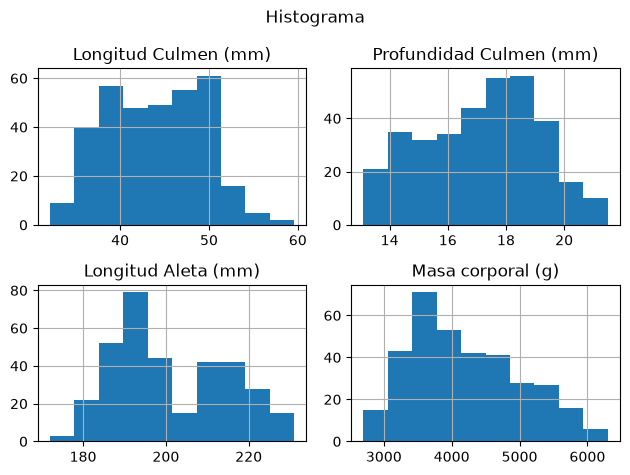

In [36]:
df.hist()
plt.suptitle("Histograma")
plt.tight_layout()
plt.show()

La hipótesis se confirma con claridad en la **longitud de la aleta**, que es bimodal: un pico alrededor de 190 mm, un valle cerca de 205 mm y un segundo grupo entre 210 y 230 mm. La **longitud del culmen** también muestra dos concentraciones (cerca de 38-40 mm y de 48-50 mm), aunque menos marcadas.

La **masa corporal** tiene un pico entre 3500 y 4000 g y una cola larga hacia la derecha hasta 6300 g, y la **profundidad del culmen** se concentra entre 17 y 19 mm con un grupo menor entre 13 y 15 mm. Ninguna de las cuatro se parece a una única distribución normal: son mezclas de las especies, lo que se verifica en el gráfico siguiente.

**Hipótesis previa:** los grupos que aparecen en los histogramas corresponden a especies distintas, y cada especie se distingue de las demás en al menos una medida.

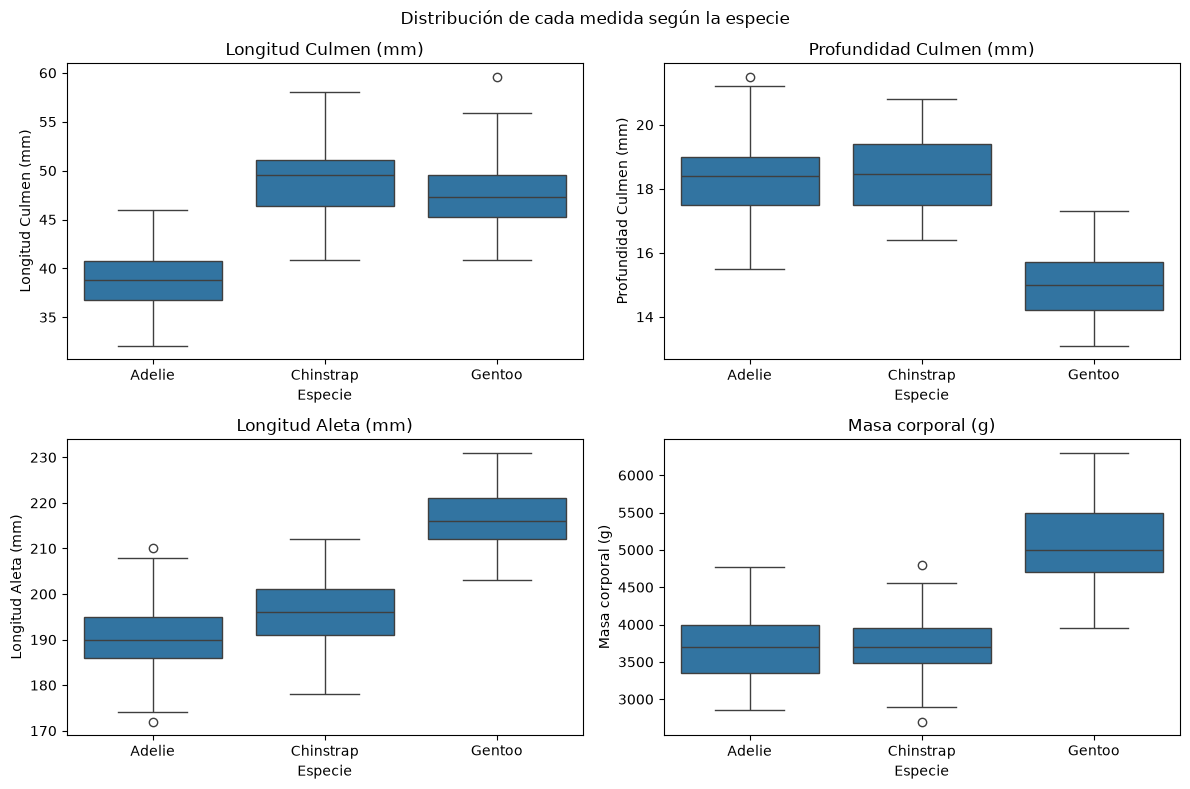

In [37]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))

for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(data=df, x="Especie", y=col, ax=ax)
    ax.set_title(col)

plt.suptitle("Distribución de cada medida según la especie")
plt.tight_layout()
plt.show()

La hipótesis se confirma, pero con un matiz: **ninguna medida por sí sola separa las tres especies**.

- **Gentoo** se diferencia de las otras dos en tres medidas: tiene el culmen menos profundo (media 15.0 mm contra 18.3-18.4), la aleta más larga (217 mm contra 190-196) y la mayor masa (5076 g contra 3700-3733). Explica el segundo pico de la aleta y la cola derecha de la masa.
- **Adelie y Chinstrap** son prácticamente iguales en profundidad del culmen y en masa, y se superponen bastante en la aleta. Solo las separa la **longitud del culmen** (38.8 mm contra 48.8 mm).
- A su vez, en longitud del culmen Chinstrap y Gentoo se solapan (48.8 contra 47.5 mm).

Por lo tanto, para distinguir las tres especies hace falta **combinar** la longitud del culmen con alguna de las otras tres medidas. Esto anticipa que una reducción a dos dimensiones puede separar bien los tres grupos, y que Adelie y Chinstrap serán los más difíciles de distinguir.

Los puntos aislados que aparecen en algunas cajas son valores atípicos **dentro de su especie**; se analizan en el tratamiento de outliers.

### Correlaciones

**Hipótesis previa:** las cuatro variables miden el tamaño del pingüino, así que un animal más grande debería tener valores mayores en todas. Esperamos correlaciones positivas entre todas las medidas.

In [38]:
def plot_correlation_heatmap(corr, title):
    ax = sns.heatmap(
        corr,
        vmin=-1, vmax=1, center=0,
        cmap=sns.diverging_palette(20, 220, n=200),
        square=True,
        annot = True,
        annot_kws = {'size': 6})
    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation=45,
        horizontalalignment='right')
    plt.title(title)
    plt.show()

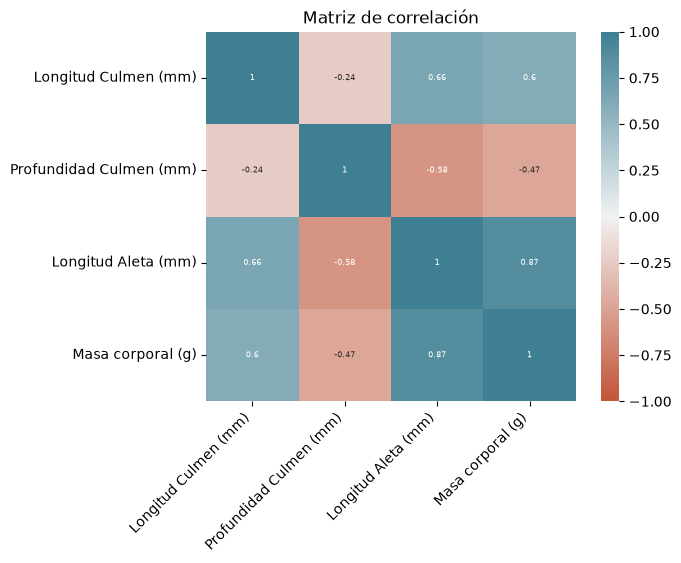

In [39]:
corr = df[num_cols].corr()
plot_correlation_heatmap(corr, "Matriz de correlación")

La hipótesis se cumple solo en parte:

- **Longitud de la aleta y masa corporal** tienen una correlación muy alta (0.87). La longitud del culmen se relaciona moderadamente con ambas (0.66 y 0.60). Estas tres variables comparten mucha información, lo que indica que es posible reducir la dimensionalidad sin perder demasiado.
- La **profundidad del culmen** contradice la hipótesis: se correlaciona de forma **negativa** con las otras tres (−0.58 con la aleta, −0.47 con la masa y −0.24 con la longitud del culmen). Según la matriz, los pingüinos más pesados tendrían el culmen menos profundo.

Este resultado no tiene sentido biológico si lo interpretamos pingüino por pingüino, así que lo analizamos separando por especie.

**Hipótesis previa:** la correlación negativa de la profundidad del culmen no se da dentro de cada especie, sino que es un efecto de mezclarlas. Gentoo es la especie más grande y al mismo tiempo la de culmen menos profundo (paso anterior), lo que por sí solo puede invertir la tendencia sobre el conjunto completo.

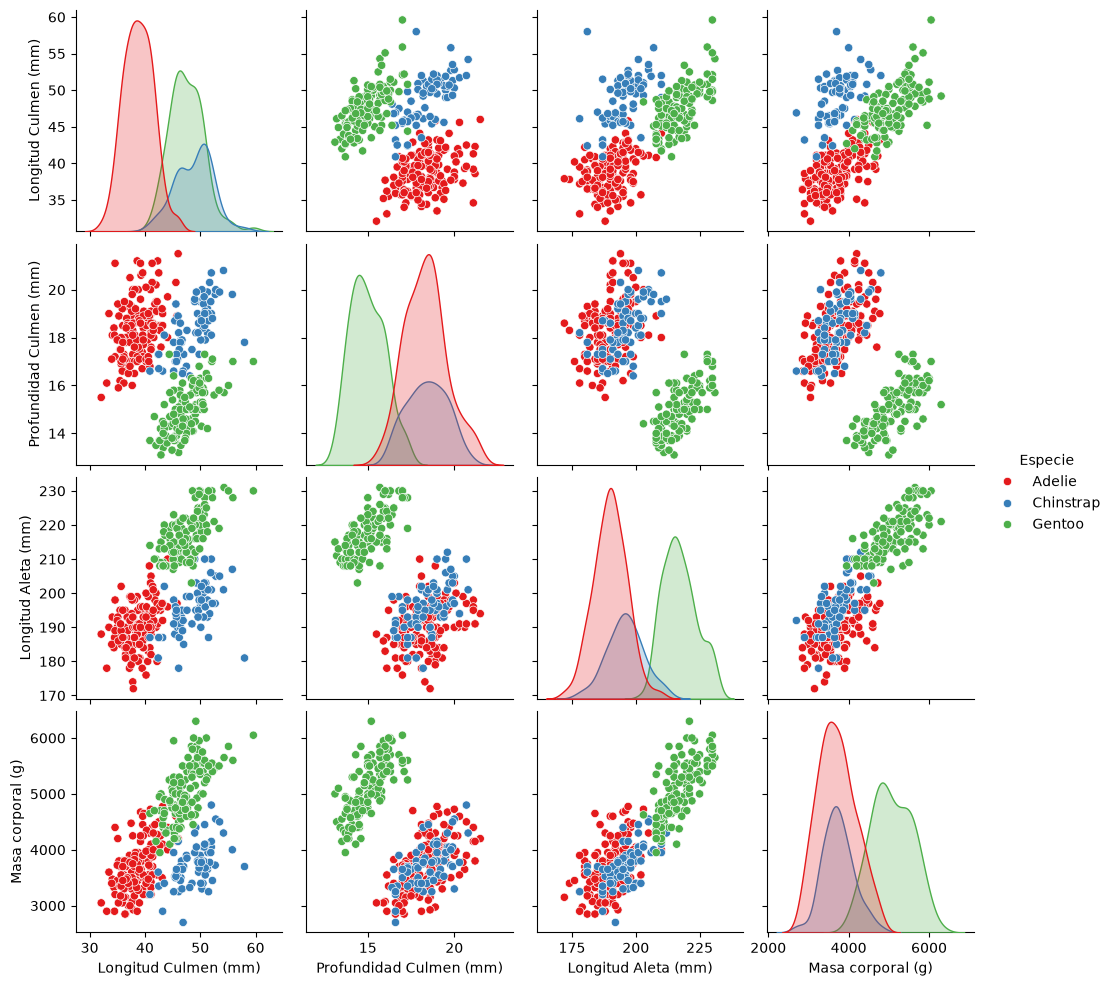

In [40]:
sns.pairplot(df, hue="Especie", palette="Set1", diag_kind="kde")
plt.show()

La hipótesis se confirma. En el gráfico de **profundidad del culmen contra masa corporal** la nube completa baja hacia la derecha, pero dentro de cada color los puntos **suben**. Calculando la correlación dentro de cada especie, la profundidad del culmen es positiva con todas las medidas: entre 0.31 y 0.58 en Adelie, entre 0.58 y 0.65 en Chinstrap y entre 0.64 y 0.72 en Gentoo. La correlación negativa del conjunto completo es producto de juntar especies con proporciones corporales distintas, y no una relación real entre las medidas.

El gráfico también muestra qué combinaciones separan las especies:

- **Longitud contra profundidad del culmen** separa las tres especies casi sin superposición: Adelie tiene culmen corto y profundo, Chinstrap largo y profundo, y Gentoo largo y poco profundo.
- La longitud del culmen combinada con la aleta o con la masa también separa bien los tres grupos.
- **Longitud de la aleta contra masa corporal** separa a Gentoo, pero Adelie y Chinstrap quedan completamente superpuestos.

Esto confirma lo visto en los boxplots: la longitud del culmen es imprescindible para distinguir Adelie de Chinstrap, y combinada con una segunda medida alcanza para separar las tres especies en dos dimensiones.

### Valores atípicos

Contamos los atípicos de cada medida con el criterio del rango intercuartílico (1.5 × IQR), primero sobre el conjunto completo.

In [41]:
## Contar cantidad de atípicos por columna
for col in num_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"Cantidad de atípicos en {col}: {len(outliers)} | {len(outliers)/len(df) * 100}")

Cantidad de atípicos en Longitud Culmen (mm): 0 | 0.0
Cantidad de atípicos en Profundidad Culmen (mm): 0 | 0.0
Cantidad de atípicos en Longitud Aleta (mm): 0 | 0.0
Cantidad de atípicos en Masa corporal (g): 0 | 0.0


Sobre el conjunto completo **no hay ningún valor atípico** en las cuatro medidas.

Sin embargo, en los boxplots por especie aparecían algunos puntos aislados. Repetimos el conteo dentro de cada especie para identificarlos.

In [42]:
filas_atipicas = []

for especie, grupo in df.groupby("Especie"):
    for col in num_cols:
        q1 = grupo[col].quantile(0.25)
        q3 = grupo[col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        outliers = grupo[(grupo[col] < lower_bound) | (grupo[col] > upper_bound)]
        if len(outliers) > 0:
            print(f"{especie} | {col}: {len(outliers)} | límites [{lower_bound:.1f}, {upper_bound:.1f}] | valores {outliers[col].tolist()}")
            filas_atipicas.extend(outliers.index)

df.loc[sorted(set(filas_atipicas))]

Adelie | Profundidad Culmen (mm): 1 | límites [15.2, 21.2] | valores [21.5]
Adelie | Longitud Aleta (mm): 2 | límites [172.5, 208.5] | valores [172.0, 210.0]
Chinstrap | Masa corporal (g): 2 | límites [2793.8, 4643.8] | valores [4800.0, 2700.0]
Gentoo | Longitud Culmen (mm): 1 | límites [38.9, 55.9] | valores [59.6]


,Especie,Longitud Culmen (mm),Profundidad Culmen (mm),Longitud Aleta (mm),Masa corporal (g),Sexo
19,Adelie,46.0,21.5,194.0,4200.0,MALE
28,Adelie,37.9,18.6,172.0,3150.0,FEMALE
130,Adelie,44.1,18.0,210.0,4000.0,MALE
190,Chinstrap,52.0,20.7,210.0,4800.0,MALE
191,Chinstrap,46.9,16.6,192.0,2700.0,FEMALE
254,Gentoo,59.6,17.0,230.0,6050.0,MALE


Dentro de las especies aparecen **6 valores atípicos**, uno por fila. **Decidimos no eliminarlos ni recortarlos**, por los siguientes motivos:

1. **Son atípicos solo dentro de su especie.** Sobre el conjunto completo todos quedan dentro del rango normal, y ninguno es un valor imposible ni un error de carga.
2. **Apenas superan los límites.** Por ejemplo, la profundidad de culmen de 21.5 mm en Adelie supera el límite de 21.2 mm, y la aleta de 172 mm queda por debajo del límite de 172.5 mm.
3. **Son coherentes con el sexo del animal.** Los valores atípicos altos pertenecen a machos (culmen de 59.6 mm en Gentoo, masa de 4800 g en Chinstrap) y los bajos a hembras (masa de 2700 g en Chinstrap, aleta de 172 mm en Adelie). Reflejan la diferencia de tamaño entre sexos y no mediciones erróneas.
4. Eliminarlos o recortarlos quitaría variabilidad real de cada especie, justamente la información que necesitan los métodos de reducción de dimensionalidad y de clustering para caracterizar los grupos.

### Codificación de variables categóricas

`Sexo` se incorpora como característica, así que la pasamos a valores numéricos: 0 para FEMALE y 1 para MALE. Al tener solo dos categorías alcanza con una única columna binaria. Verificamos antes que no quede ninguna categoría sin mapear.

In [43]:
sexo_map = {
    "FEMALE": 0,
    "MALE": 1,
}

# Chequeamos que no haya quedado ningún valor sin mapear
print("Categorías sin mapear:", set(df["Sexo"]) - set(sexo_map.keys()))

df["Sexo"] = df["Sexo"].map(sexo_map)
df["Sexo"].value_counts()

Categorías sin mapear: set()


Sexo
1    172
0    170
Name: count, dtype: int64

`Especie` es la variable objetivo, por lo que no se codifica ni forma parte de las características: la separamos en `y` y la usaremos solo para colorear los gráficos y contrastar los resultados. `X` queda con las cuatro medidas y el sexo.

In [44]:
X = df.drop(columns="Especie")
y = df["Especie"]

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)
X.head()

Dimensiones de X: (342, 5)
Dimensiones de y: (342,)


,Longitud Culmen (mm),Profundidad Culmen (mm),Longitud Aleta (mm),Masa corporal (g),Sexo
0,39.1,18.7,181.0,3750.0,1
1,39.5,17.4,186.0,3800.0,0
2,40.3,18.0,195.0,3250.0,0
4,36.7,19.3,193.0,3450.0,0
5,39.3,20.6,190.0,3650.0,1


`X` tiene 342 muestras y 5 características, todas numéricas, e `y` contiene la especie de cada una de esas 342 muestras.

### Estandarización

Las características tienen escalas muy distintas (la masa corporal está en miles de gramos y la profundidad del culmen en decenas de milímetros). Como los métodos siguientes se basan en varianzas y distancias, estandarizamos para que todas contribuyan en igual medida.

In [45]:
scaler = StandardScaler().set_output(transform="pandas")
X_std = scaler.fit_transform(X)
X_std.head()

,Longitud Culmen (mm),Profundidad Culmen (mm),Longitud Aleta (mm),Masa corporal (g),Sexo
0,-0.884499,0.785449,-1.418347,-0.564142,0.994169
1,-0.811126,0.126188,-1.062250,-0.501703,-1.005865
2,-0.664380,0.430462,-0.421277,-1.188532,-1.005865
4,-1.324737,1.089724,-0.563715,-0.938776,-1.005865
5,-0.847812,1.748985,-0.777373,-0.689020,0.994169


Verificamos que cada característica haya quedado con media 0 y desvío 1.

In [46]:
X_std.describe()

,Longitud Culmen (mm),Profundidad Culmen (mm),Longitud Aleta (mm),Masa corporal (g),Sexo
count,3.420000e+02,3.420000e+02,3.420000e+02,3.420000e+02,3.420000e+02
mean,1.454327e-15,-1.412775e-15,-8.310441e-16,4.155221e-17,-4.934325e-17
std,1.001465e+00,1.001465e+00,1.001465e+00,1.001465e+00,1.001465e+00
min,-2.168526e+00,-2.054446e+00,-2.059320e+00,-1.875362e+00,-1.005865e+00
25%,-8.615697e-01,-7.866355e-01,-7.773731e-01,-8.138982e-01,-1.005865e+00
50%,9.686524e-02,7.547549e-02,-2.788381e-01,-1.895079e-01,9.941690e-01
75%,8.397670e-01,7.854492e-01,8.606705e-01,6.846384e-01,9.941690e-01
max,2.875868e+00,2.205397e+00,2.142618e+00,2.620248e+00,9.941690e-01


Todas las características quedan con media 0. El desvío que muestra `describe()` es 1.001 y no exactamente 1 porque pandas calcula el desvío muestral (divide por n − 1), mientras que la estandarización usa el poblacional (divide por n). Con 342 muestras la diferencia es despreciable.

Ahora los rangos son comparables: todas las medidas quedan aproximadamente entre −2 y 3. La columna `Sexo` toma solo dos valores (−1.006 y 0.994) porque es binaria.

### Resumen de la consigna 1

**Limpieza.** El conjunto pasó de 347 a **342 muestras**:

| Tratamiento | Efecto |
|---|---|
| Columnas finales vacías | Eliminadas |
| Nombres de especie inconsistentes | Unificados en Adelie, Chinstrap y Gentoo |
| 2 filas sin ninguna medida | Eliminadas |
| 11 faltantes de `Sexo` (incluido el valor `.`) | 2 se eliminaron junto con sus filas; los otros 9 se imputaron con la moda de su especie |
| 3 filas duplicadas | Eliminadas |
| 6 valores atípicos dentro de su especie | Conservados: son variabilidad real y coherente con el sexo |

**Preparación.** `Sexo` se codificó como binaria y `Especie` se separó como variable objetivo (`y`), que no participa de los cálculos. Las 5 características de `X` se estandarizaron en `X_std`, que es la matriz con la que se trabaja en el resto del trabajo.

**Observaciones que orientan el análisis siguiente:**

- **Gentoo** se distingue claramente de las otras dos especies por su culmen menos profundo, su aleta más larga y su mayor masa.
- **Adelie y Chinstrap** solo se diferencian por la longitud del culmen, así que se espera que sean las especies más difíciles de separar, tanto en las proyecciones como en el clustering.
- La longitud de la aleta y la masa corporal están muy correlacionadas (0.87) y la longitud del culmen se relaciona moderadamente con ambas: hay información redundante, por lo que se espera que pocas componentes principales retengan la mayor parte de la varianza.
- La correlación negativa de la profundidad del culmen con las demás medidas es un efecto de mezclar especies y no se da dentro de ninguna de ellas.
- Combinando la longitud del culmen con una segunda medida, las tres especies se separan en dos dimensiones, así que se espera que una proyección en 2D las muestre en grupos diferenciados y que el número de clusters que mejor representa los datos esté cerca de 3.